# Web Scraping & Product Price Analysis – Air Conditioners (Amazon India)
**Stage 7 – Data Visualization** (simplified, beginner version)

Pipeline position: **7 of 8**

## Objective
Draw charts with Matplotlib: histogram, bar charts, pie chart, scatter plot, box plot and a correlation heatmap. Each chart is saved as a PNG in the `charts` folder.

## Step 1 – Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Folder that holds all the CSV files of the project.
# (In Google Colab: upload the CSV files and change this to "/content/")
DATA = "../0. DataSet/"

print("Setup complete.")

Setup complete.


In [4]:
import os

df = pd.read_csv("Air_Conditioners_Cleaned.csv")

os.makedirs("charts", exist_ok=True)       # folder for the saved charts
print("Loaded:", df.shape)

Loaded: (652, 15)


## Chart 1 – Histogram of prices
A histogram shows how many listings fall in each price range.

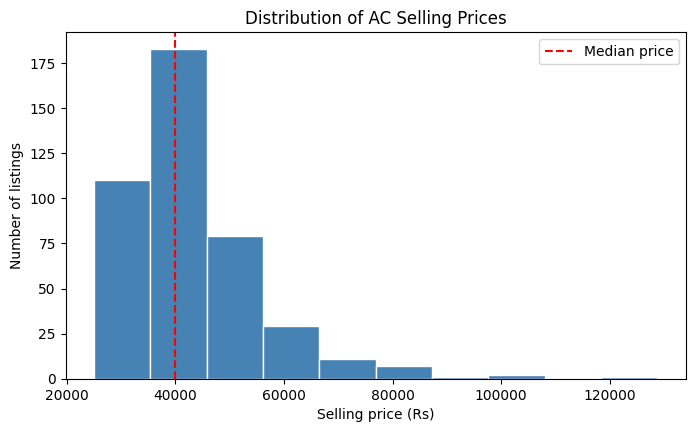

In [5]:
prices = df["discount_price"].dropna()

plt.figure(figsize=(8, 4.5))
plt.hist(prices, bins=10, color="steelblue", edgecolor="white")
plt.axvline(prices.median(), color="red", linestyle="--", label="Median price")
plt.title("Distribution of AC Selling Prices")
plt.xlabel("Selling price (Rs)")
plt.ylabel("Number of listings")
plt.legend()
plt.savefig("charts/01_price_distribution.png")
plt.show()

## Chart 2 – Average price by brand (horizontal bar chart)

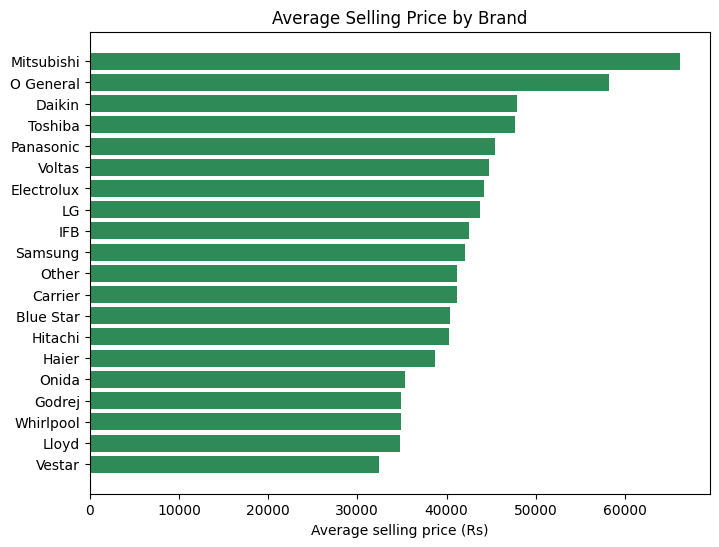

In [6]:
brand_price = df.groupby("brand")["discount_price"].mean().dropna().sort_values()

plt.figure(figsize=(8, 6))
plt.barh(brand_price.index, brand_price.values, color="seagreen")
plt.title("Average Selling Price by Brand")
plt.xlabel("Average selling price (Rs)")
plt.savefig("charts/02_avg_price_by_brand.png")
plt.show()

## Chart 3 – Number of listings by brand

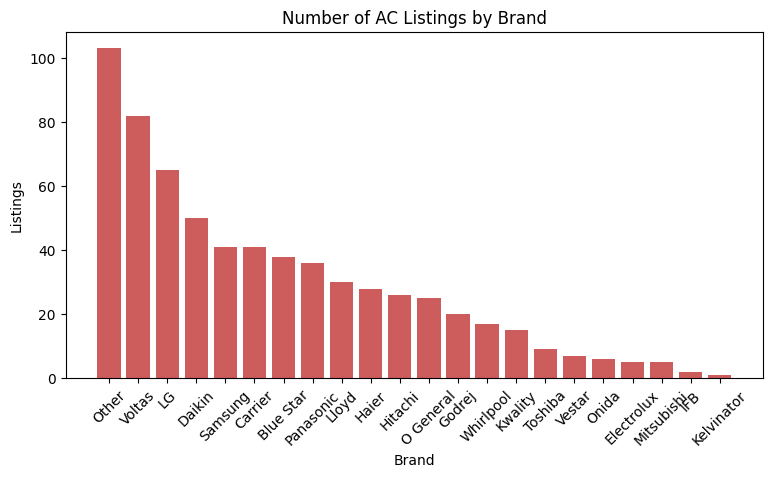

In [7]:
brand_count = df["brand"].value_counts()

plt.figure(figsize=(9, 4.5))
plt.bar(brand_count.index, brand_count.values, color="indianred")
plt.title("Number of AC Listings by Brand")
plt.xlabel("Brand")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.savefig("charts/03_listings_by_brand.png")
plt.show()

## Chart 4 – Energy star share (pie chart)

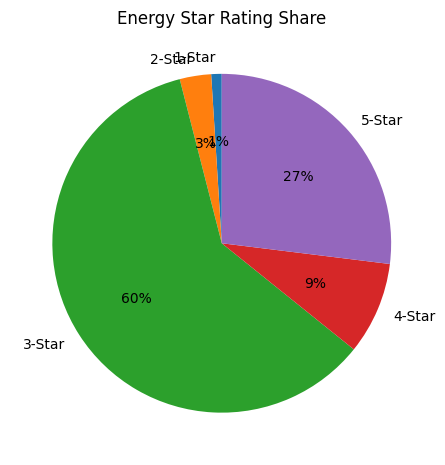

In [8]:
star_count = df["energy_star"].dropna().astype(int).value_counts().sort_index()
star_labels = []
for star in star_count.index:
    star_labels.append(str(star) + "-Star")

plt.figure(figsize=(5.5, 5.5))
plt.pie(star_count.values, labels=star_labels, autopct="%1.0f%%", startangle=90)
plt.title("Energy Star Rating Share")
plt.savefig("charts/04_energy_star_share.png")
plt.show()

## Chart 5 – Average price by tonnage

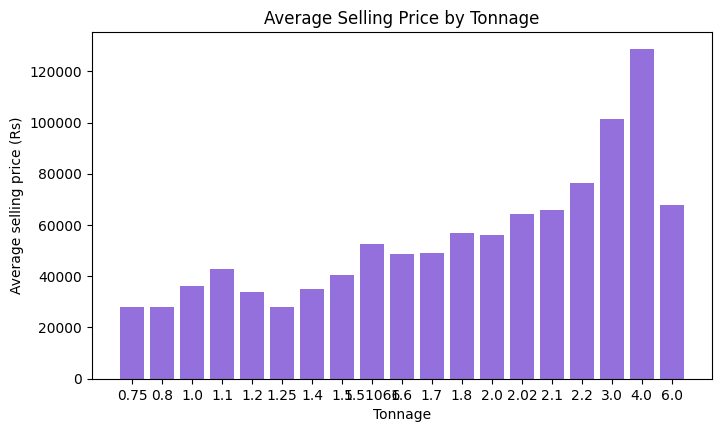

In [9]:
ton_price = df.groupby("tonnage")["discount_price"].mean().dropna()

plt.figure(figsize=(8, 4.5))
plt.bar(ton_price.index.astype(str), ton_price.values, color="mediumpurple")
plt.title("Average Selling Price by Tonnage")
plt.xlabel("Tonnage")
plt.ylabel("Average selling price (Rs)")
plt.savefig("charts/05_avg_price_by_tonnage.png")
plt.show()

## Chart 6 – Scatter plot: price vs rating
Each dot is one AC.

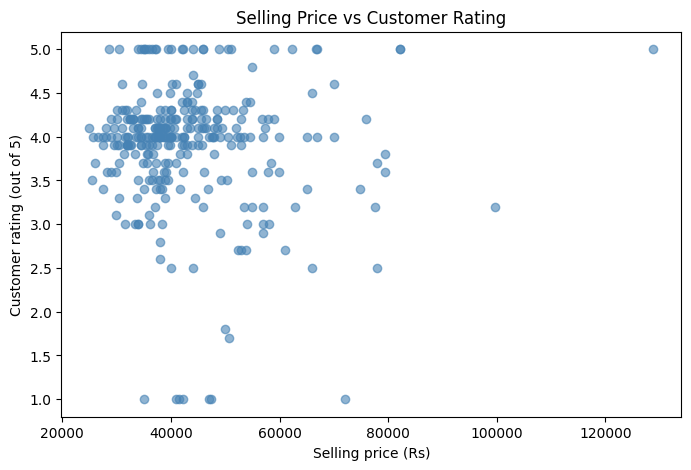

In [10]:
both = df.dropna(subset=["discount_price", "ratings"])

plt.figure(figsize=(8, 5))
plt.scatter(both["discount_price"], both["ratings"], alpha=0.6, color="steelblue")
plt.title("Selling Price vs Customer Rating")
plt.xlabel("Selling price (Rs)")
plt.ylabel("Customer rating (out of 5)")
plt.savefig("charts/06_price_vs_rating.png")
plt.show()

## Chart 7 – Discount percentage

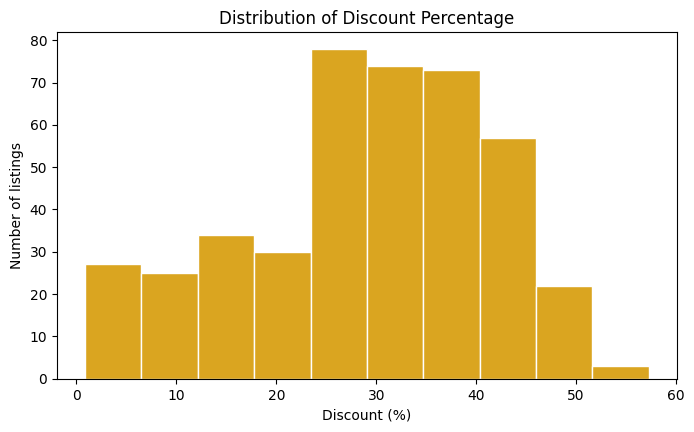

In [11]:
discounts = df["discount_percent"].dropna()

if len(discounts) > 1:
    plt.figure(figsize=(8, 4.5))
    plt.hist(discounts, bins=10, color="goldenrod", edgecolor="white")
    plt.title("Distribution of Discount Percentage")
    plt.xlabel("Discount (%)")
    plt.ylabel("Number of listings")
    plt.savefig("charts/07_discount_distribution.png")
    plt.show()
else:
    print("Not enough verified discounts - chart skipped.")

## Chart 8 – Box plot: price for each star rating
A box plot shows the median (middle line), the middle 50% of prices (box) and unusual values (dots).

/tmp/ipykernel_1799/2297322201.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


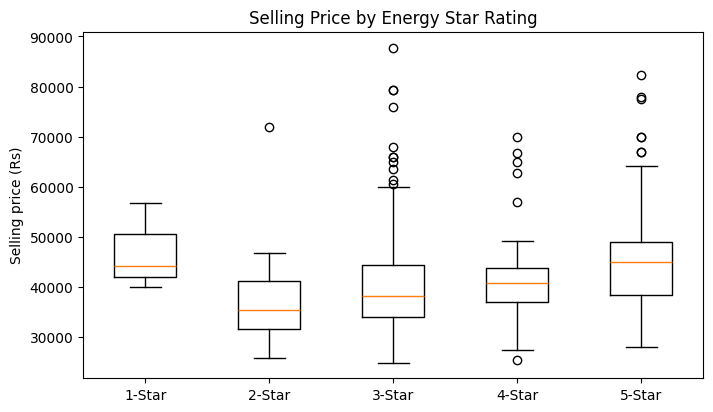

In [12]:
data_to_plot = []
labels = []
for star in [1, 2, 3, 4, 5]:
    star_prices = df.loc[df["energy_star"] == star, "discount_price"].dropna()
    if len(star_prices) > 0:
        data_to_plot.append(star_prices)
        labels.append(str(star) + "-Star")

plt.figure(figsize=(8, 4.5))
plt.boxplot(data_to_plot, labels=labels)
plt.title("Selling Price by Energy Star Rating")
plt.ylabel("Selling price (Rs)")
plt.savefig("charts/08_price_by_star_boxplot.png")
plt.show()

## Chart 9 – Correlation heatmap
Colours show the correlation: red = rise together, blue = move opposite.

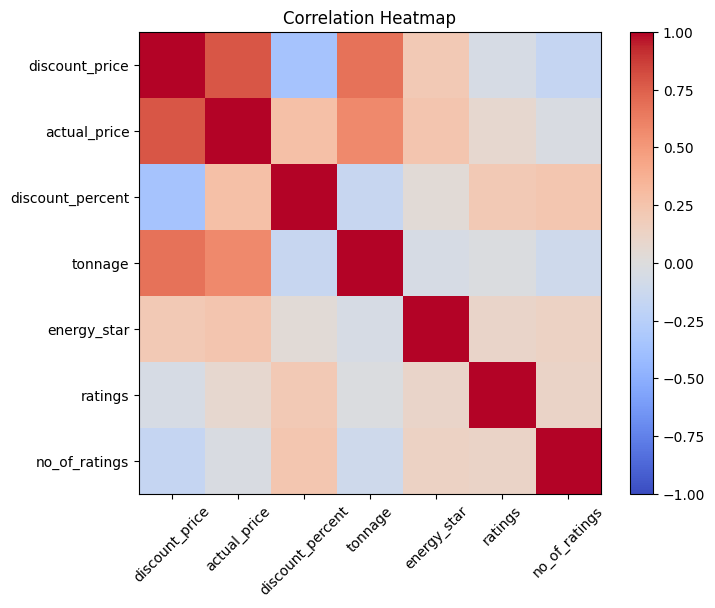

In [13]:
columns = ["discount_price", "actual_price", "discount_percent", "tonnage", "energy_star", "ratings", "no_of_ratings"]
corr = df[columns].corr()

plt.figure(figsize=(7.5, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(columns)), columns, rotation=45)
plt.yticks(range(len(columns)), columns)
plt.title("Correlation Heatmap")
plt.savefig("charts/09_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Saved charts

In [14]:
print(sorted(os.listdir("charts")))

['01_price_distribution.png', '02_avg_price_by_brand.png', '03_listings_by_brand.png', '04_energy_star_share.png', '05_avg_price_by_tonnage.png', '06_price_vs_rating.png', '07_discount_distribution.png', '08_price_by_star_boxplot.png', '09_correlation_heatmap.png']


**Output of Stage 7:** 9 PNG charts.  **Next → Stage 8: Results & Interpretation.**